In [1]:
import sys
sys.path.insert(0, '../')
from lib import *

%matplotlib inline

DEBUG = False;


In [2]:
WEEK="APSAIA_VIS_2";

path="/pc/choozdsk01/users/romeo/LAB/"+WEEK+"/joython/"
Runs=open_runs_table("../macros/"+WEEK+".xlsx")
Calib_run=Runs[(Runs["Type"]=="Calibration")].iloc[2] #2nd calib run, middle voltage 


<Figure size 1280x960 with 0 Axes>

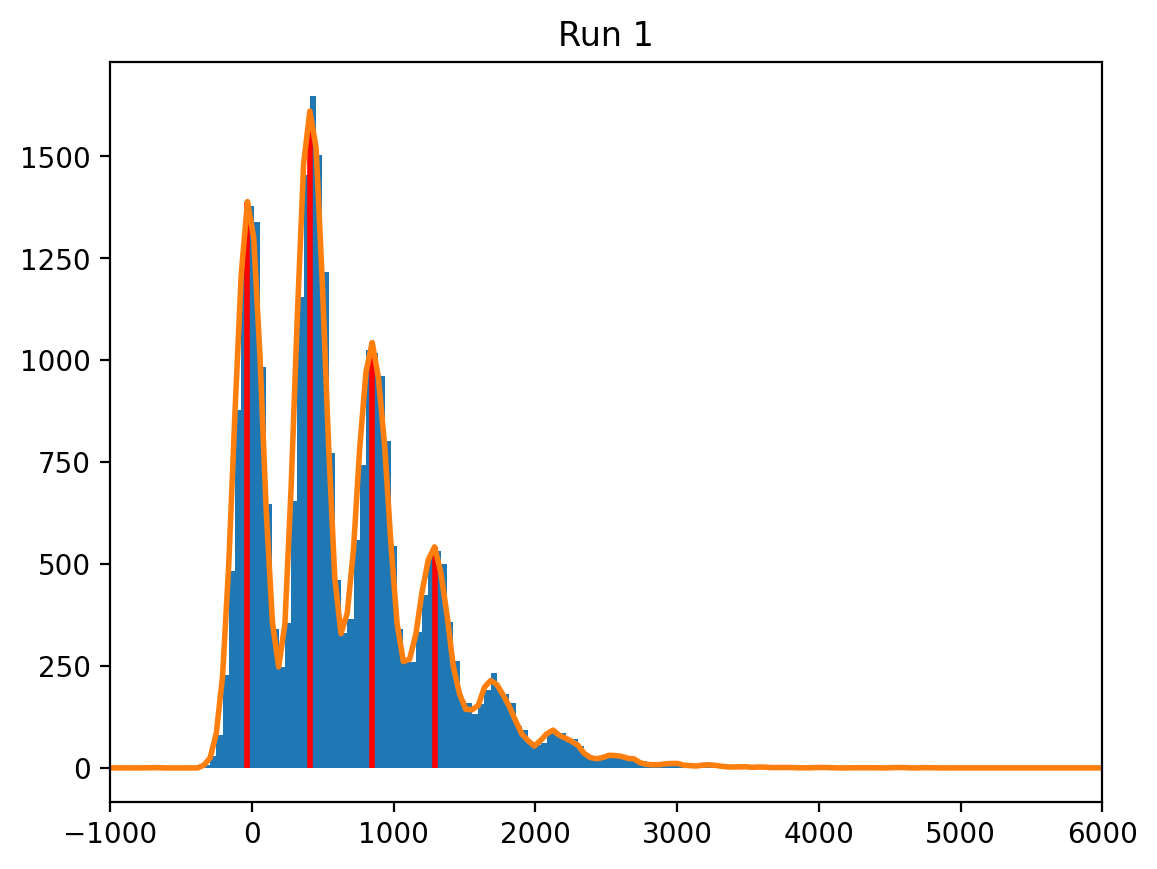

<Figure size 1280x960 with 0 Axes>

In [16]:
from scipy.signal import find_peaks, savgol_filter
plt.style.use('default')

## Encontramos los picos en el histograma de carga

for run in [1]:

    for ch in [0]:
        
        plt.figure(dpi=200)
        plt.title("Run "+str(run))
        run_path=path+"run"+str(run).zfill(2)+"/";
        compress=False
        Pedestal_vars=open_run_var(run_path,"Pedestal_vars",[ch],compressed=compress)
        Charge_vars  =open_run_var(run_path ,"Charge_vars" ,[ch],compressed=compress)
        Peak_vars    =open_run_var(run_path ,"Peak_vars"   ,[ch],compressed=compress)
        # plt.hist(Peak_vars[ch]["Peak"],bins=200,range=(0,400),label="Pedestal",histtype="step",lw=2)  
        plt.hist(Charge_vars[ch]["ChargeRangeAverageWvf"],bins=250,range=(-1e3,1e4))
        counts, bins=np.histogram(Charge_vars[ch]["ChargeRangeAverageWvf"],bins=250,range=(-1e3,1e4))
        
        #suavizamos el histogram, hace mas obvios los picos
        smoothed = savgol_filter(counts, 5, 3) # window size 51, polynomial order 3 

        peaks=find_peaks(smoothed, height=500)
        plt.vlines(bins[peaks[0]], 0, smoothed[peaks[0]], lw=2, color="red")
        
        plt.plot(bins[:-1], smoothed, lw=2)
        
# plt.semilogy()
plt.xlim(-1e3,0.6e4)

plt.figure(dpi=200)




array([-1000.,  -956.,  -912.,  -868.,  -824.,  -780.,  -736.,  -692.,
        -648.,  -604.,  -560.,  -516.,  -472.,  -428.,  -384.,  -340.,
        -296.,  -252.,  -208.,  -164.,  -120.,   -76.,   -32.,    12.,
          56.,   100.,   144.,   188.,   232.,   276.,   320.,   364.,
         408.,   452.,   496.,   540.,   584.,   628.,   672.,   716.,
         760.,   804.,   848.,   892.,   936.,   980.,  1024.,  1068.,
        1112.,  1156.,  1200.,  1244.,  1288.,  1332.,  1376.,  1420.,
        1464.,  1508.,  1552.,  1596.,  1640.,  1684.,  1728.,  1772.,
        1816.,  1860.,  1904.,  1948.,  1992.,  2036.,  2080.,  2124.,
        2168.,  2212.,  2256.,  2300.,  2344.,  2388.,  2432.,  2476.,
        2520.,  2564.,  2608.,  2652.,  2696.,  2740.,  2784.,  2828.,
        2872.,  2916.,  2960.,  3004.,  3048.,  3092.,  3136.,  3180.,
        3224.,  3268.,  3312.,  3356.,  3400.,  3444.,  3488.,  3532.,
        3576.,  3620.,  3664.,  3708.,  3752.,  3796.,  3840.,  3884.,
      

/afs/ciemat.es/user/r/rodrigoa/.local/lib/python3.6/site-packages/ipykernel_launcher.py:19: MatplotlibDeprecationWarning:

Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.



(-1000.0, 5000.0)

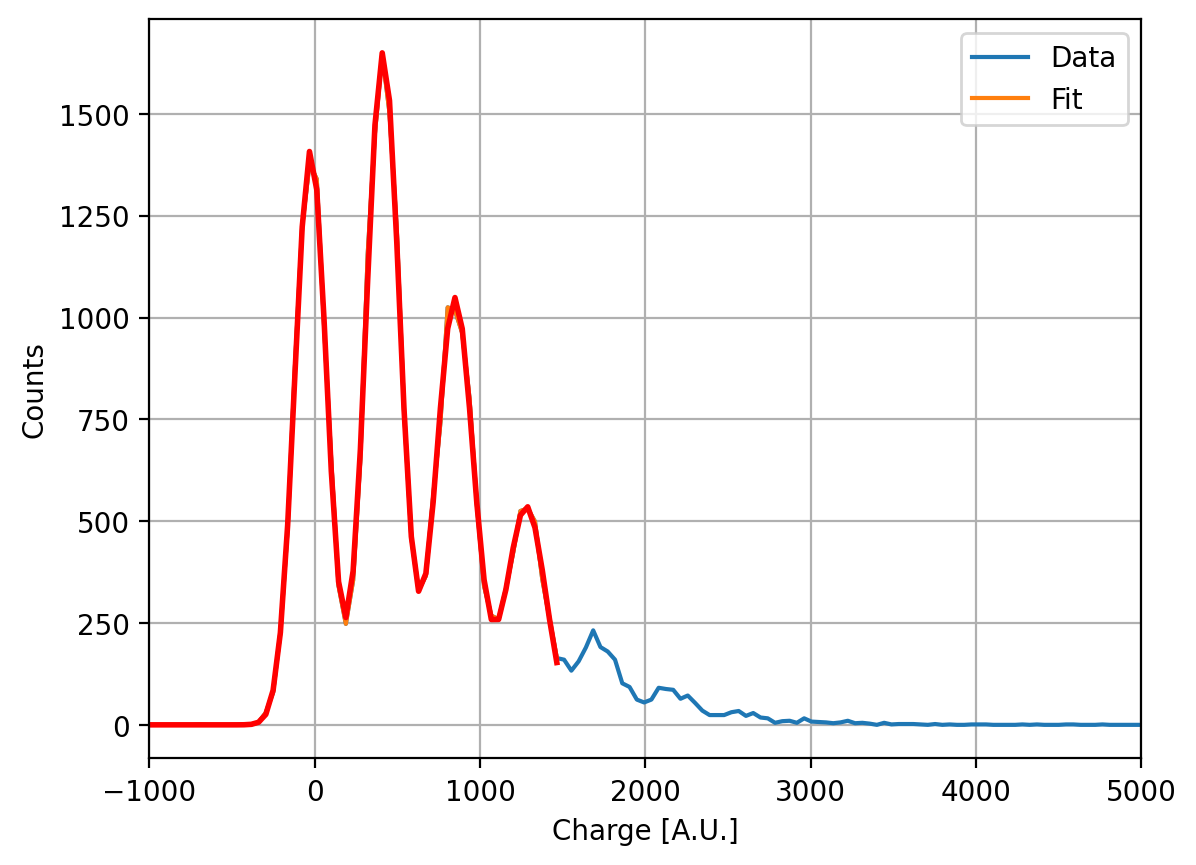

In [28]:
def gauss(x,a,x0,sigma):
    return a*np.exp(-0.5*np.power((x-x0)/sigma,2))

def gaussian_train(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        height = params[i]
        center = params[i+1]
        width  = params[i+2]
        y      +=  gauss(x, height, center, width)
    return y

def fit_gaussians(x, y, *p0):
    assert x.shape == y.shape, "Input arrays must have the same shape."
    # try:
    popt, pcov = curve_fit(gaussian_train, x,y, p0=p0[0])
    fit_y=gaussian_train(x,*popt)
    chi_squared = np.sum((y[abs(fit_y)>0.1] - fit_y[abs(fit_y)>0.1]) ** 2 / fit_y[abs(fit_y)>0.1]) / (y.size - len(popt))
    fig = plt.axes()
    plt.plot(x, y, label='data')
    plt.plot(x, fit_y, 'red', label='fit',linewidth=2)
    plt.grid()
    return popt,fig, chi_squared
    # except:
    #     print("Fit failed.")



plt.figure(dpi=200)

add=5

bins_to_fit=bins    [:peaks[0][-1]+add]
counts_to_fit=counts[:peaks[0][-1]+add]

params=np.zeros(len(peaks[0])*3)
params[0::3]=peaks[1]["peak_heights"]
params[1::3]=bins[peaks[0]]
params[2::3]=1e2
plt.plot(bins[:-1],counts)
vars,fig,qs=fit_gaussians(bins_to_fit,counts_to_fit,params)
# print(vars*1e-6)
# fig.set_xlim([-1e4,0.98e4])
fig.set_xlabel("Charge [A.U.]")
fig.set_ylabel("Counts")
fig.legend(["Data","Fit"],loc="upper right")

gains=vars[1::3]-vars[1]
gains=gains[1:]-gains[0:-1]
# fig.text(0.4e8,430,"X-ARAPUCA Gain [1e6] \n =%0.2f" % (gains[0]*1e-6));
plt.xlim(-1e3,0.5e4)

In [37]:
not_the_gain_yet=np.mean(gains)


SAMPLING=4e-9 # ns seconds
BITS= 16384 #2^14)
DYNAMIC_RANGE= 2 #volts
AMP= 250  ## this is not true, the Amp is this /50 Ohms  from the ADC  resistance. Antonio includes the 50 Ohms in the ADC  in the measure. THIS IS NOT the amp,  which would be for exmaple: 250 Ohms/50 Ohms = 5s
e_charge=1.60217663 * 1e-19

#                           ADCs to V     ticks to sec          C to e-      still need to correct by Gain of specific run
ADCxTicks2e=       DYNAMIC_RANGE/BITS     * SAMPLING  / AMP  /e_charge

not_the_gain_yet*ADCxTicks2e/1E6

5.2970788454339806

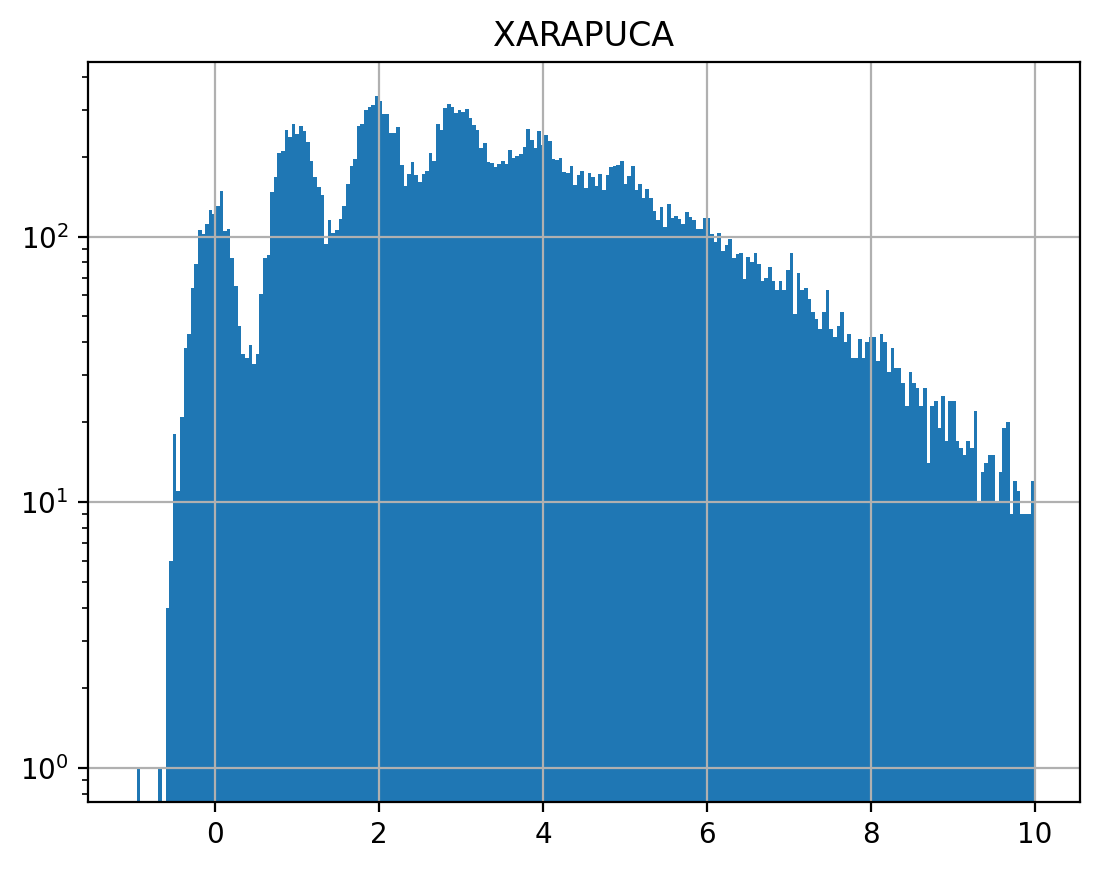

In [72]:
##OLD CALIBRATIONS:

arapuca_factor=GetGains("APSAIA_VIS",4,3,MODE="PE")

# for run in [10]:

    # for ch in [5]:
        
    #     plt.figure(dpi=200)
    #     plt.title("XARAPUCA")
    #     run_path=path+"run"+str(run).zfill(2)+"/";
    #     compress=False
    #     Pedestal_vars=open_run_var(run_path,"Pedestal_vars",[ch],compressed=compress)
    #     Charge_vars  =open_run_var(run_path ,"Charge_vars" ,[ch],compressed=compress)
    #     Peak_vars    =open_run_var(run_path ,"Peak_vars"   ,[ch],compressed=compress)

    #     plt.hist(Charge_vars[ch]["ChargeRangeAverageWvf"]*arapuca_factor,bins=250,range=(-1,10))
    #     plt.grid()


for run in [4]:
    for ch in [3]:
        
        plt.figure(dpi=200)
        plt.title("XARAPUCA")
        run_path=path+"run"+str(run).zfill(2)+"/";
        compress=False
        Pedestal_vars=open_run_var(run_path,"Pedestal_vars",[ch],compressed=compress)
        Charge_vars  =open_run_var(run_path ,"Charge_vars" ,[ch],compressed=compress)
        Peak_vars    =open_run_var(run_path ,"Peak_vars"   ,[ch],compressed=compress)

    
        sipm_factor=1/600
        plt.hist(Charge_vars[ch]["ChargeRangeAverageWvf"]*sipm_factor,bins=250,range=(-1,10))
        plt.grid()
        plt.semilogy()
        # plt.


# Run con mucha luz

(-1.0, 5.0)

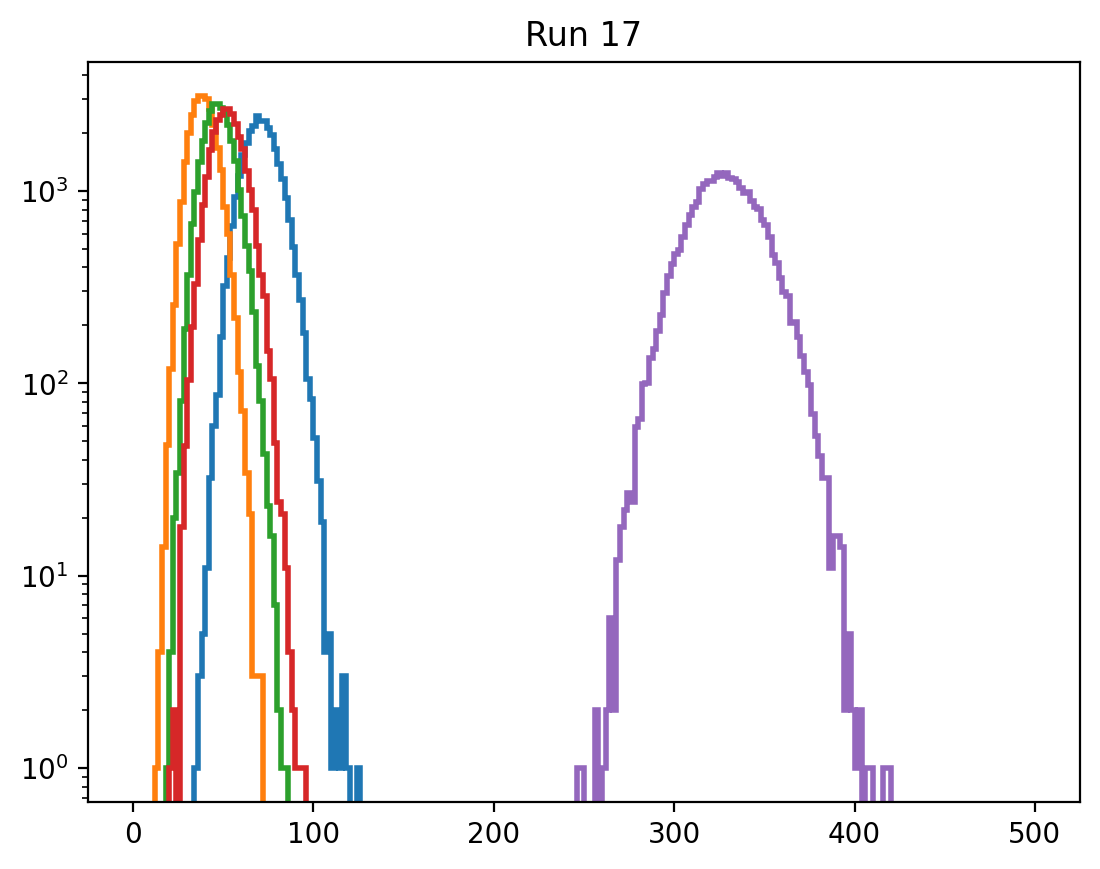

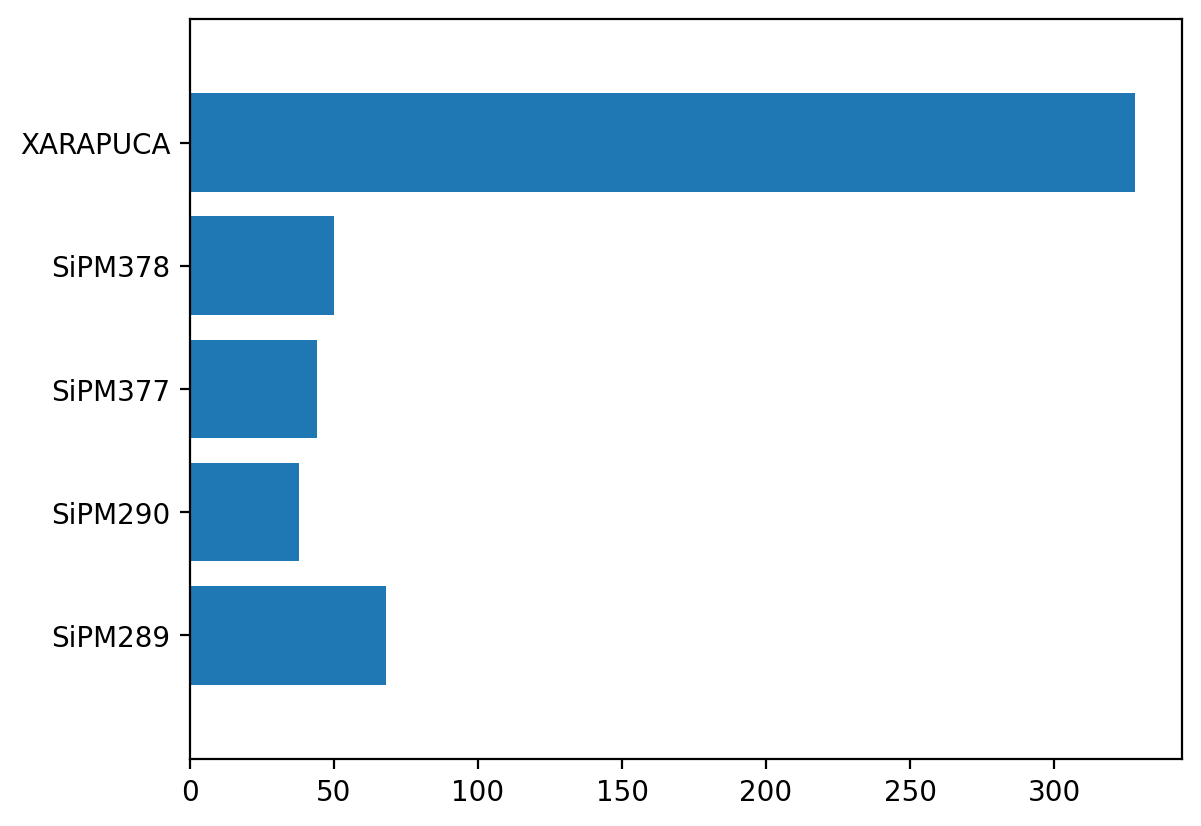

In [84]:


plt.figure(dpi=200)


peaks={}

for run in [17]:

    for ch in [0,1,3,4,5]:
        plt.title("Run "+str(run))
        run_path=path+"run"+str(run).zfill(2)+"/";
        compress=False
        Pedestal_vars=open_run_var(run_path,"Pedestal_vars",[ch],compressed=compress)
        Charge_vars  =open_run_var(run_path ,"Charge_vars" ,[ch],compressed=compress)
        Peak_vars    =open_run_var(run_path ,"Peak_vars"   ,[ch],compressed=compress)
        # plt.hist(Peak_vars[ch]["Peak"],bins=200,range=(0,400),label="Pedestal",histtype="step",lw=2)
        
        if ch<5:
            factor=sipm_factor
        else:
            factor=arapuca_factor
            
        counts,bins,_=plt.hist(Charge_vars[ch]["ChargeRangePed"]*factor,bins=250,range=(0,500),histtype="step",lw=2,label="Ch "+str(ch))
        peak=bins[np.argmax(counts)]
        peaks[ch]=peak

plt.semilogy()

charges=np.array(list((peaks.values())))

plt.figure (dpi=200)
plt.barh(  Runs["ChannelName"].iloc[0]  , charges )
# plt.xlim(0,1.1)
plt.ylim(-1,5)


#  Gross PDE stimation

In [95]:
Ratio_g4=38.25
PDE_SiPMs=21

charge_SiPMs=charges[-2]+charges[-3]
charge_xarapuca=charges[-1]
print("Charge in SiPMs:",charge_SiPMs)  
print("Charge in XARAPUCA:",charge_xarapuca)

ratio_measured=charge_xarapuca/charge_SiPMs

PDE_XA=PDE_SiPMs*ratio_measured/Ratio_g4

print("PDE XARAPUCA:",PDE_XA)

Charge in SiPMs: 94.0
Charge in XARAPUCA: 328.0
PDE XARAPUCA: 1.9157279933249898
